In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
time = ['1 days', '2 days', '4 days', '7 days', '11 days', '17 days',
              '25 days', '37 days', '53 days', '77 days', '111 days', '158 days',
              '226 days', '323 days', '1.3 years', '1.8 years', '2.6 years',
              '3.6 years', '5.2 years', '7.3 years', '10.4 years', '14.8 years',
              '21.1 years', '30.0 years']

# Load data sample

In [3]:
from google.colab import drive
import os
drive.mount("/content/drive")
#!ls "/content/drive/My Drive/train_data_set"
#os.listdir("/content/drive/My Drive/train_data_set")


Mounted at /content/drive


In [4]:
with np.load("/content/drive/My Drive/train_data_set/data_0006.npz") as data:
    print(data.keys())
    for key, value in data.items():
        globals()[key] = value
    nz = porosity.shape[0]
    print('reservoir dimension is:', porosity.shape)
    print('gas saturation dimension is:', gas_saturation.shape)
    print('pressure buildup dimension is:', pressure_buildup.shape)

KeysView(NpzFile '/content/drive/My Drive/train_data_set/data_0006.npz' with keys: porosity, perm_r, perm_z, inj_rate, temperature...)
reservoir dimension is: (55, 200)
gas saturation dimension is: (55, 200, 24)
pressure buildup dimension is: (55, 200, 24)


In [5]:
for key in data.keys():
  print(key), print(globals()[key].shape)

porosity
(55, 200)
perm_r
(55, 200)
perm_z
(55, 200)
inj_rate
()
temperature
()
depth
()
Swi
()
lam
()
perf_interval
(2,)
pressure_buildup
(55, 200, 24)
gas_saturation
(55, 200, 24)


In [6]:
inj_rate

array(0.31158581)

In [7]:
perf_interval[1]

np.int64(37)

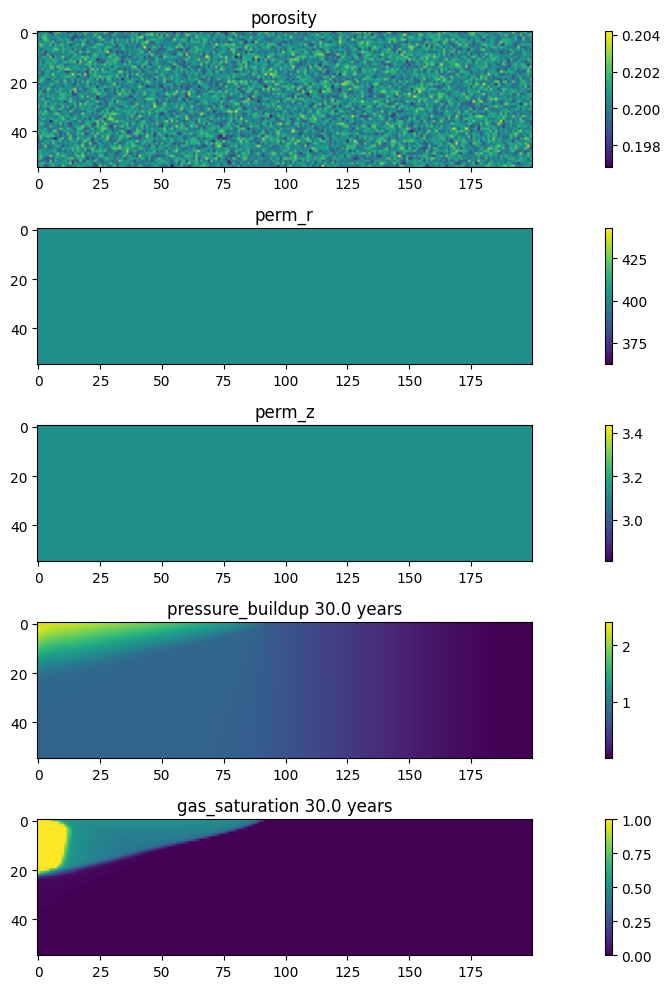

In [8]:
plt.figure(figsize=(15,10))
plt.subplot(5,1,1)
plt.imshow(porosity[:,:])
plt.colorbar()
plt.title(f'porosity')

plt.subplot(5,1,2)
plt.imshow(perm_r[:,:])
plt.colorbar()
plt.title(f'perm_r')

plt.subplot(5,1,3)
plt.imshow(perm_z[:,:])
plt.colorbar()
plt.title(f'perm_z')

plt.subplot(5,1,4)
plt.imshow(pressure_buildup[:,:,-1])
plt.colorbar()
plt.title(f'pressure_buildup {time[-1]}')

plt.subplot(5,1,5)
plt.imshow(gas_saturation[:,:,-1])
plt.colorbar()
plt.title(f'gas_saturation {time[-1]}')
plt.tight_layout()
plt.show()

# Notice that your data is in an irregular grid with gradually coarsening lateral cells

In [9]:
# Convert data to real spatial dimension for better visulization
dx = np.cumsum(3.5938*np.power(1.035012, range(200))) + 0.1
X, Y = np.meshgrid(dx, np.linspace(0,200,num = nz))

def pcolor(x):
    plt.jet()
    plt.xlim([0,4000])
    return plt.pcolor(X, Y, np.flipud(x))

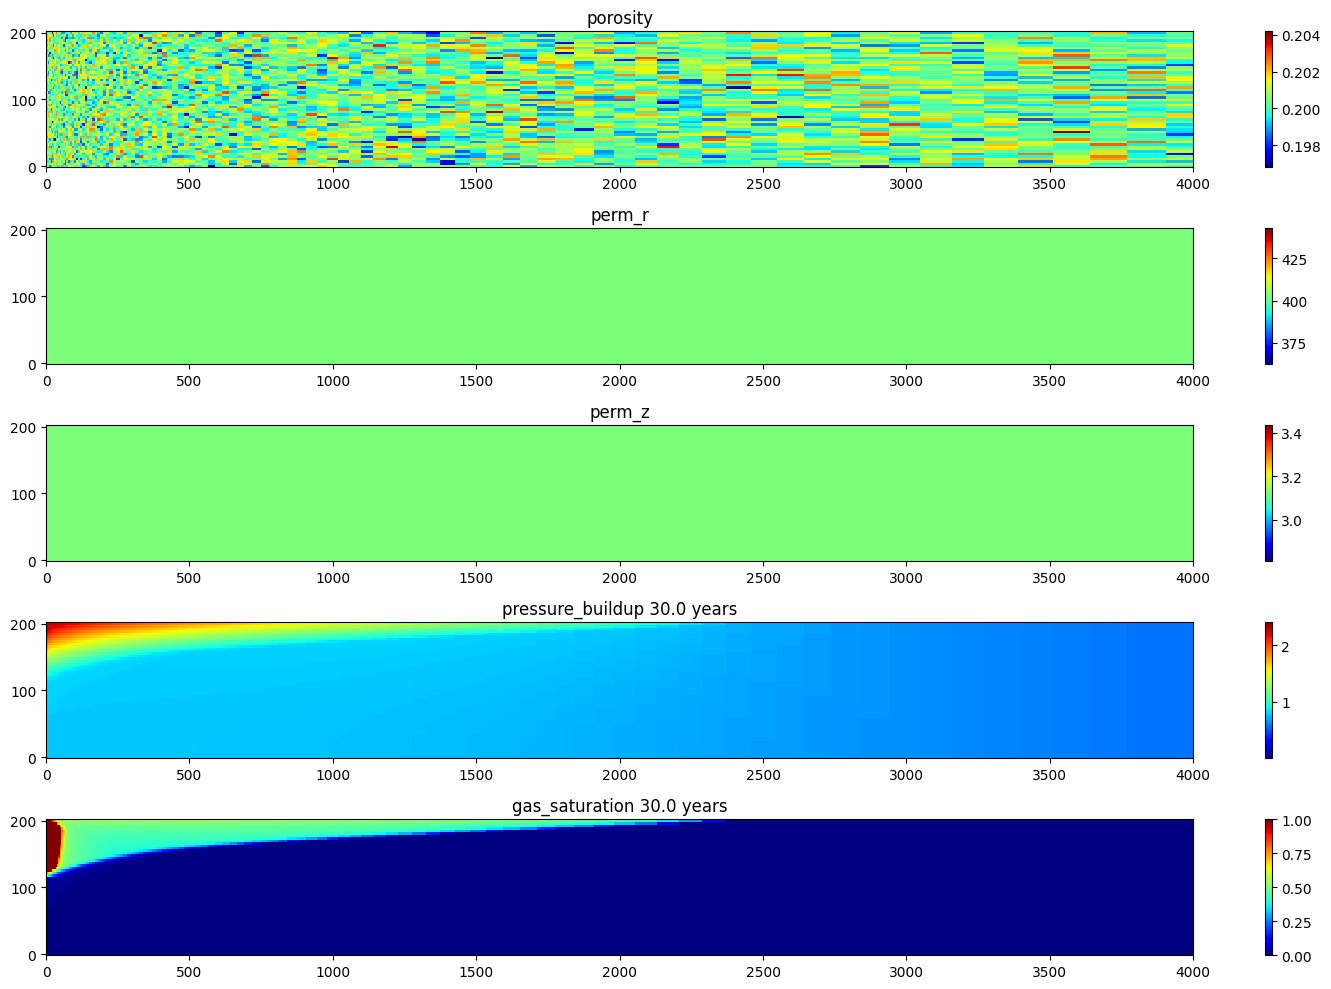

In [10]:
plt.figure(figsize=(15,10))
plt.subplot(5,1,1)
pcolor(porosity[:,:])
plt.colorbar()
plt.title(f'porosity')

plt.subplot(5,1,2)
pcolor(perm_r[:,:])
plt.colorbar()
plt.title(f'perm_r')

plt.subplot(5,1,3)
pcolor(perm_z[:,:])
plt.colorbar()
plt.title(f'perm_z')

plt.subplot(5,1,4)
pcolor(pressure_buildup[:,:,-1])
plt.colorbar()
plt.title(f'pressure_buildup {time[-1]}')

plt.subplot(5,1,5)
pcolor(gas_saturation[:,:,-1])
plt.colorbar()
plt.title(f'gas_saturation {time[-1]}')
plt.tight_layout()
plt.show()

# Building the dataset/ dataloader

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
#from torchsummary import summary


from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit

device = 'cpu'
if torch.cuda.device_count() > 0 and torch.cuda.is_available():
    print("Cuda installed! Running on GPU!")
    device = 'cuda'
else:
    print("No GPU available!")
    device = 'cpu'

def set_seed(seed):
    """
    Use this to set ALL the random seeds to a fixed value and take out any randomness from cuda kernels
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False  # uses the inbuilt cudnn auto-tuner to find the fastest convolution algorithms. Useful when inputs do not change size -
    torch.backends.cudnn.enabled   = False

    return True

No GPU available!


In [13]:
class reservoir_dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        # let's just store what we input
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        # should return the number of files in the directory
        return len(os.listdir(self.root_dir))

    def __getitem__(self, index):
        # need to be able to do this as list
        input_list = []
        output_list = []

        if isinstance(index, int):
            index = [index]

        for idx in index:
            # Convert idx to marker for file
            idx = str(idx)
            L = len(idx)
            idx = idx.rjust(4,"0")
            # That should work

            # Now we load in the file
            with np.load(self.root_dir+"data_"+idx+".npz") as data:
                for key, value in data.items():
                    globals()[key] = value

            # Now we are going to create a numpy array with the data
            input_array = np.zeros((10,96,200))
            nz = porosity.shape[0]
            input_array[0,:nz,:] = porosity
            input_array[1,:nz,:] = perm_r
            input_array[2,:nz,:] = perm_z
            input_array[3,:,:] = np.ones((96,200)) * inj_rate
            input_array[4,:,:] = np.ones((96,200)) * temperature
            input_array[5,:,:] = np.ones((96,200)) * depth
            input_array[6,:,:] = np.ones((96,200)) * Swi
            input_array[7,:,:] = np.ones((96,200)) * lam
            input_array[8,:,:] = np.ones((96,200)) * perf_interval[0]
            input_array[9,:,:] = np.ones((96,200)) * perf_interval[1]

            input_tensor = torch.from_numpy(input_array)

            output_array = np.zeros((2,96,200,24))
            output_array[0,:nz,:,:] = pressure_buildup
            output_array[1,:nz,:,:] = gas_saturation # does this work?

            output_tensor = torch.from_numpy(output_array)

            input_list.append(input_tensor)
            output_list.append(output_tensor)

        sample = torch.stack(input_list,dim=0),torch.stack(output_list,dim=0)

        if self.transform:
            sample = self.transform(sample)

        return sample

# Okay, i think this should work



In [14]:
# let's test our dataset:
res_dataset = reservoir_dataset("/content/drive/My Drive/train_data_set/")


In [15]:
#for test in enumerate(res_dataset):
    #print(np.shape(test[1][1]))
#     #fig = plt.figure()

#     if test[0] == 3:
#       plt.imshow(test[1][1][0][0,:,:,0])


In [ ]:
# Now we need a transformer
# before we do that, we need to take mean and std values across all our data
# we should also move permeabilities to logspace


counter = 0
input_means = torch.zeros((1,10))
output_means = torch.zeros((1,2))
input_mse = torch.zeros((1,10))
output_mse = torch.zeros((1,2))

for test in enumerate(res_dataset):
    counter +=1

    input_means += torch.mean(test[1][0],(2,3))
    output_means += torch.mean(test[1][1],(2,3,4))
    input_mse += torch.sum(torch.square(test[1][0]),(2,3))
    output_mse += torch.sum(torch.square(test[1][1]),(2,3,4))
    # There's an argument to be made that we should've done this before padding,
    # but oh well
    if counter % 100 == 0:
        print(counter)
    if counter == 2000:
        break

input_std = torch.sqrt((input_mse-torch.square(input_means/2000))/(counter*96*200))
output_std = torch.sqrt((output_mse-torch.square(output_means/2000))/(counter*96*200))


100
200


In [ ]:
print(input_means/2000)
print(output_means/2000)
print(input_std)
print(output_std)


print(type(data.keys))

In [ ]:
np.shape(input_std)

In [ ]:
means = torch.concat((input_means/2000,output_means/2000),dim=1)
stds = torch.concat((input_std,output_std),dim=1)
labels = ["porosity",
          "perm_r",
          "perm_z",
          "inj_rate",
          "temperature",
          "depth",
          "Swi",
          "lam",
          "perf_interval1",
          "perf_interval_2",
          "pressure_buildup",
          "gas_saturation"]

means = means.numpy()
stds = stds.numpy()

means=means[0,:]
stds=stds[0,:]

import pandas as pd
df = pd.DataFrame(np.transpose(np.array([means, stds])),index=labels,
                  columns=["mean","std"])

# import pandas as pd
# df1 = pd.DataFrame(means[0],index=labels)
# df2 = pd.DataFrame(stds[0],index=labels)
# df = pd.DataFrame([df1,df2])
df.head()
df.to_csv("dataset_stats.csv")

In [ ]:
means

###
 Let's build the transform function really quick then

In [ ]:

def transform1(sample,mean=means,stds=stds):
    # takes in a tuple of input/output tensors, returns the same

    inputs = sample[0]
    outputs = sample[1]

    for idx in range(10):
        inputs[:,idx,:,:] = (inputs[:,idx,:,:] - torch.ones_like(inputs[:,idx,:,:])*means[idx])/stds[idx]

    for idx in range(2):
        outputs[:,idx,:,:] = (outputs[:,idx,:,:] - torch.ones_like(outputs[:,idx,:,:])*means[idx+10])/stds[idx+10]

    return (inputs,outputs)

In [ ]:
res_dataset2 = reservoir_dataset("/content/drive/My Drive/train_data_set/",transform=transform1)
for test in enumerate(res_dataset2):
    print(np.shape(test[1][1]))
    if test[0]==30:
      break

In [ ]:
plt.imshow(test[1][1][0,1,:,:,23])
plt.colorbar()

In [ ]:
np.shape(demo_output[0])

# This is the section where we build the model

In [ ]:
# Build model
# Taken from Q1 of deep learning assessment

# I will follow closely the lecture notes for the afternoon of day 6


# Conv block
class ConvBlock(nn.Module):
  # this can stay
    def __init__(self,c_in,c_out):
        super().__init__()
        self.c1 = nn.Conv2d(c_in, c_out, kernel_size=3, padding=1)
        # can add normalisation here as we go
        self.act = nn.ReLU() # starting out with ReLu


    def forward(self,x):
        x = self.act(self.c1(x))
        return x

# Step down -- convolutions and max pooling (explore other types of pooling)
class downstep(nn.Module):
  # this can stay
    def __init__(self,c_in, c_out):
        super().__init__()
        self.c1 = ConvBlock(c_in,c_out)
        self.c2 = ConvBlock(c_out,c_out)
        self.p1 = nn.MaxPool2d((2,2))

    def forward(self, x):
        x = self.c1(x)
        x = self.c2(x)
        d = self.p1(x)
        # we will use x as our skip connection
        # The effect of this downstep block will be to half both the spatial dims
        # And change the number of channels from c_in to c_out
        return d, x

# Step up
class upstep(nn.Module):
    #this can stay
    def __init__(self, c_in, c_out):
        super().__init__()
        self.ct = nn.ConvTranspose2d(c_in, c_out, kernel_size=2, stride=2, padding=0)
        # This will double the image dims
        self.c1 = ConvBlock(2*c_out, c_out)
        # We will concatenate the skip connections, so we need 2*c_out
        self.c2 = ConvBlock(c_out, c_out)

    def forward(self, x, skip):
        x = self.ct(x)
        x = torch.cat((x, skip), axis=1) # axis 0 is batch, axis 1 is channels
        x = self.c1(x)
        x = self.c2(x)
        return x


In [ ]:
# Let's test that the above functions do what we want
test_input = torch.ones(1,1,64,64)
print(test_input.shape)
CV_test = ConvBlock(1,4)
print(CV_test(test_input).shape)
down_test = downstep(1,4)
down, skip = down_test(test_input)
print(skip.shape, down.shape)
up_test = upstep(4,4)
print(up_test(down,skip).shape)

In [ ]:
# Full UNET
class unet1(nn.Module):
    def __init__(self, channels_in, channels_out):
        super().__init__()
        # we are going to begin by going down 2 times
        # Increase channels from 1 > 64
        self.d1 = downstep(channels_in,64)
        # Increase channels from 64 > 128
        self.d2 = downstep(64,128)
        # Increase channels from 128 > 256
        self.d3 = downstep(128,256)


        # Now we'll have our bottleneck
        self.bn1 = ConvBlock(256,512)
        self.bn2 = ConvBlock(512,512)



        # Now we go up twice
        self.u1 = upstep(512,256)
        self.u2 = upstep(256,128)
        self.u3 = upstep(128,64)
        # And our output step
        self.output = nn.Conv2d(64,channels_out,kernel_size=1,padding=0)





    def forward(self, x):
        x, skip1 = self.d1(x)
        x, skip2 = self.d2(x)
        x, skip3 = self.d3(x)
        x = self.bn1(x)
        x = self.bn2(x)
        x = self.u1(x, skip3)
        x = self.u2(x, skip2)
        x = self.u3(x, skip1)
        x = self.output(x).reshape([1,2,96,200,24])
        return x

In [ ]:
test_input = torch.ones(1,10,96,200)
# Let's test this works
test_unet = unet1(10,48)
test_output = test_unet(test_input)
test_output.shape
# All is well

In [ ]:
# Now we will test that we can load and save our model (1)
test_path = "test_model.pt"
torch.save(test_unet, test_path)

In [ ]:
loaded_model = torch.load(test_path, weights_only=False)
loaded_model # delightful
loaded_model.eval()
# for this to work, we need to have run the cells which define our model

# Time to train

In [ ]:
# hyperparameters:
batch_size = 64
lr = 1e-4 # do we want to do dynamic learning rate at some point?
nepochs = 10

In [ ]:
# datasets
from torch.utils.data import random_split

all_data = reservoir_dataset("/content/drive/My Drive/train_data_set/", transform=transform1) # there is currently data leakage here
train_data, valid_data = random_split(all_data,[0.8,0.2])

# dataloaders
train_loader = DataLoader(train_data,batch_size=batch_size,shuffle=True,num_workers=0)
valid_loader = DataLoader(valid_data,batch_size=batch_size,shuffle=False,num_workers=0)

In [ ]:
# we need a function which takes a batch of outputs and formats them correctly

def mod_output_tensor(Tensor):
    C = np.shape(Tensor[-4])
    T = np.shape(Tensor[-1])
    new_Tensor = torch.zeros()


In [ ]:
# Overfit on one batch
# Try overfitting the model

model = unet1(10,48).to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

batch_data = next(iter(train_loader))

# This is effectively the same as the training function, but instead
# of using a dataloader, we will use the same batch of training data over and over

np.shape(batch_data[0])

def overfit_train(model, batch_data, criterion, optimizer, device):
    model.train()
    train_loss=0
    optimizer.zero_grad()
    # need to fix inputs and outputs
    recon = model(batch_data[0].to(device))
    actual = batch_data[1].to(device)

    loss = criterion(recon, actual)

    loss.backward()
    train_loss += loss.item()
    optimizer.step()

    avg_loss = train_loss / batch_size
    return avg_loss

def overfit_valid(model, dataloader, criterion, device):
    model.eval()
    valid_loss = 0.
    with torch.no_grad():
        info = next(iter(dataloader))
        input = info[0].to(device)
        target = info[1].to(device)
        output = model(input)
        target = target
        loss = criterion(output, target)
        valid_loss += loss*input.size(0)
        valid_loss = valid_loss / batch_size
        return valid_loss.detach().cpu()

#print(batch_data["t1"].shape)
#plt.imshow(batch_data[0][0],cmap="gray")

train_losses = []
valid_losses = []
for epoch in range(50):
    train_loss = overfit_train(model, batch_data, criterion, optimizer, device)
    train_losses.append(train_loss)
    valid_loss = overfit_valid(model, valid_loader, criterion, device)
    valid_losses.append(valid_loss)
    print(epoch)

    clear_output(wait=True)
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.plot(train_losses, label='Training Loss')
    ax.plot(valid_losses, label="Validation Loss")
    ax.legend()
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    plt.show()

    print(f'Epoch {epoch+1}, Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

    # Can also add in validation comparison